**MISSION ANALYSIS**

In [1]:
# ============================================================
# TBM-X — RAYMER AIRCRAFT DESIGN
# PHASE I — MISSION ANALYSIS
# ============================================================
#
# Objective:
#   Calculate the TBM-X mission fuel fraction using
#   physically meaningful mission segments.
#
# Methodology:
#   - Raymer conceptual aircraft design methodology
#   - Breguet range relation for cruise
#   - Atmospheric / aerodynamic relations
#
# Important:
#   Benchmark aircraft are used for validation,
#   NOT for forcing the model to match the benchmark..
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("TBM-X — Raymer Mission Analysis")
print("Mission model initialized.")

TBM-X — Raymer Mission Analysis
Mission model initialized.


**TBM-X MISSION REQUIREMENTS**

In [2]:
# ============================================================
# 1. TBM-X MISSION REQUIREMENTS
# ============================================================

mission = {

    # Design range
    "range_km": 3000,

    # Cruise altitude
    "cruise_altitude_ft": 25000,

    # Cruise speed
    "cruise_speed_kt": 300,

    # Reserve
    "reserve_time_min": 45,

    # Loiter speed
    "loiter_speed_kt": 120,

    # Number of crew
    "crew": 1,

    # Number of passengers
    "passengers": 5,
}

mission

{'range_km': 3000,
 'cruise_altitude_ft': 25000,
 'cruise_speed_kt': 300,
 'reserve_time_min': 45,
 'loiter_speed_kt': 120,
 'crew': 1,
 'passengers': 5}

**STANDARD ATMOSPHERE — SIMPLIFIED ISA**

In [3]:
# ============================================================
# 2. STANDARD ATMOSPHERE — SIMPLIFIED ISA
# ============================================================

def isa_atmosphere(altitude_m):
    """
    Simplified ISA atmosphere model.

    Parameters
    ----------
    altitude_m : float
        Geometric altitude [m]

    Returns
    -------
    T : float
        Temperature [K]

    P : float
        Pressure [Pa]

    rho : float
        Air density [kg/m^3]
    """

    T0 = 288.15       # K
    P0 = 101325.0     # Pa
    L = 0.0065        # K/m
    R = 287.05        # J/(kg K)
    g = 9.80665       # m/s^2

    T = T0 - L * altitude_m

    P = P0 * (
        T / T0
    ) ** (
        g / (R * L)
    )

    rho = P / (R * T)

    return T, P, rho

**CRUISE ATMOSPHERE**

In [4]:
# ============================================================
# 3. CRUISE ATMOSPHERE
# ============================================================

FT_TO_M = 0.3048
KT_TO_MPS = 0.514444

cruise_altitude_m = (
    mission["cruise_altitude_ft"]
    * FT_TO_M
)

cruise_speed_mps = (
    mission["cruise_speed_kt"]
    * KT_TO_MPS
)

T_cruise, P_cruise, rho_cruise = (
    isa_atmosphere(cruise_altitude_m)
)

print(f"Altitude     : {cruise_altitude_m:.1f} m")
print(f"Temperature  : {T_cruise:.2f} K")
print(f"Pressure     : {P_cruise:.0f} Pa")
print(f"Density      : {rho_cruise:.4f} kg/m³")
print(f"Cruise speed : {cruise_speed_mps:.2f} m/s")

Altitude     : 7620.0 m
Temperature  : 238.62 K
Pressure     : 37601 Pa
Density      : 0.5489 kg/m³
Cruise speed : 154.33 m/s


******************

**Cruise Aerodynamics:**

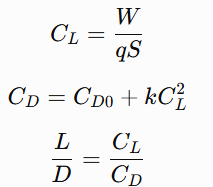

**Breguet:**

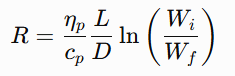

So;

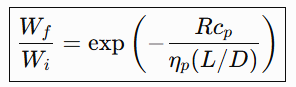

Range

  ↓

Breguet

  ↓

Fuel Fraction
  
  ↓

MTOW

  ↓

Empty Weight

  ↓

MTOW

  ↓

Convergence

In [5]:
# ============================================================
# TBM-X — RAYMER AIRCRAFT DESIGN
# PHASE I — MISSION ANALYSIS
# ============================================================
#
# Methodology:
#   Daniel P. Raymer — Aircraft Conceptual Design
#
# Main objectives:
#   1. Define TBM-X mission
#   2. Model cruise aerodynamics
#   3. Calculate L/D
#   4. Calculate cruise fuel fraction
#   5. Model reserve / loiter
#   6. Calculate total mission fuel fraction
#   7. Feed the result back into weight sizing
#
# IMPORTANT:
#   Parameters are explicitly classified as:
#
#   - RAYMER / METHOD
#   - BENCHMARK
#   - ENGINEERING ASSUMPTION
#
# No parameter is presented as a "real TBM value"
# unless supported by benchmark data.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("TBM-X — Raymer Mission Analysis")
print("Mission model initialized.")


TBM-X — Raymer Mission Analysis
Mission model initialized.


**PARAMETER SOURCE / PROVENANCE**

In [6]:
# ============================================================
# 1. PARAMETER SOURCE / PROVENANCE
# ============================================================

parameter_sources = pd.DataFrame([
    
    ["Range", "RAYMER / REQUIREMENT",
     "TBM-X design requirement"],
    
    ["Cruise speed", "RAYMER / REQUIREMENT",
     "TBM-X design requirement"],
    
    ["Cruise altitude", "ENGINEERING ASSUMPTION",
     "Initial conceptual-design assumption"],
    
    ["CD0", "ENGINEERING ASSUMPTION",
     "Initial clean-aircraft drag assumption; to be validated"],
    
    ["k", "ENGINEERING ASSUMPTION",
     "Initial induced-drag factor; derived later from AR/e"],
    
    ["Propeller efficiency", "ENGINEERING ASSUMPTION",
     "Initial turboprop conceptual value"],
    
    ["BSFC", "ENGINEERING ASSUMPTION",
     "Initial turboprop conceptual value; benchmark validation required"],
    
    ["Wing area", "BENCHMARK / DESIGN",
     "Initial value informed by benchmark aircraft"],
    
], columns=[
    "parameter",
    "classification",
    "comment"
])

parameter_sources

,parameter,classification,comment
0,Range,RAYMER / REQUIREMENT,TBM-X design requirement
1,Cruise speed,RAYMER / REQUIREMENT,TBM-X design requirement
2,Cruise altitude,ENGINEERING ASSUMPTION,Initial conceptual-design assumption
3,CD0,ENGINEERING ASSUMPTION,Initial clean-aircraft drag assumption; to be ...
4,k,ENGINEERING ASSUMPTION,Initial induced-drag factor; derived later fro...
5,Propeller efficiency,ENGINEERING ASSUMPTION,Initial turboprop conceptual value
6,BSFC,ENGINEERING ASSUMPTION,Initial turboprop conceptual value; benchmark ...
7,Wing area,BENCHMARK / DESIGN,Initial value informed by benchmark aircraft


**MISSION REQUIREMENTS**

In [7]:
# ============================================================
# 2. TBM-X MISSION REQUIREMENTS
# ============================================================

mission = {

    # --------------------------------------------------------
    # Primary mission
    # --------------------------------------------------------
    "range_km": 3000,

    # Cruise
    "cruise_speed_kt": 300,
    "cruise_altitude_ft": 25000,

    # Reserve / loiter
    "reserve_time_min": 45,
    "loiter_speed_kt": 120,

    # Aircraft configuration
    "crew": 1,
    "passengers": 5,

    # Initial wing area
    #
    # This is NOT a final TBM-X geometry.
    # It is an initial conceptual value.
    #
    "wing_area_m2": 18.0,
}

mission

{'range_km': 3000,
 'cruise_speed_kt': 300,
 'cruise_altitude_ft': 25000,
 'reserve_time_min': 45,
 'loiter_speed_kt': 120,
 'crew': 1,
 'passengers': 5,
 'wing_area_m2': 18.0}

UNIT CONVERSIONS

In [8]:
# ============================================================
# 3. UNIT CONVERSIONS
# ============================================================

FT_TO_M = 0.3048
M_TO_FT = 1 / FT_TO_M

KT_TO_MPS = 0.514444
MPS_TO_KT = 1 / KT_TO_MPS

KM_TO_M = 1000.0
NM_TO_KM = 1.852

LB_TO_KG = 0.45359237
KG_TO_LB = 1 / LB_TO_KG

HP_TO_W = 745.699872

MIN_TO_S = 60.0
H_TO_S = 3600.0

**STANDARD ATMOSPHERE — ISA**

In [9]:
# ============================================================
# 4. STANDARD ATMOSPHERE — ISA
# ============================================================

def isa_atmosphere(altitude_m):
    """
    Simplified ISA atmosphere model.

    Parameters
    ----------
    altitude_m : float
        Altitude [m]

    Returns
    -------
    temperature_K : float
    pressure_Pa : float
    density_kg_m3 : float
    """

    T0 = 288.15
    P0 = 101325.0

    lapse_rate = 0.0065

    R = 287.05
    g = 9.80665

    T = T0 - lapse_rate * altitude_m

    P = P0 * (
        T / T0
    ) ** (
        g / (R * lapse_rate)
    )

    rho = P / (R * T)

    return T, P, rho

**CRUISE ATMOSPHERE**

In [10]:
# ============================================================
# 5. CRUISE ATMOSPHERE
# ============================================================

cruise_altitude_m = (
    mission["cruise_altitude_ft"]
    * FT_TO_M
)

cruise_speed_mps = (
    mission["cruise_speed_kt"]
    * KT_TO_MPS
)

T_cruise, P_cruise, rho_cruise = (
    isa_atmosphere(cruise_altitude_m)
)

print(f"Cruise altitude : {cruise_altitude_m:.1f} m")
print(f"Temperature     : {T_cruise:.2f} K")
print(f"Pressure        : {P_cruise:.0f} Pa")
print(f"Density         : {rho_cruise:.4f} kg/m³")
print(f"Cruise speed    : {cruise_speed_mps:.2f} m/s")

Cruise altitude : 7620.0 m
Temperature     : 238.62 K
Pressure        : 37601 Pa
Density         : 0.5489 kg/m³
Cruise speed    : 154.33 m/s


**Aerodynamic assumptions**

In [11]:
# ============================================================
# 6. AERODYNAMIC PARAMETERS
# ============================================================
#
# Classification:
#   ENGINEERING ASSUMPTION
#
# These values are NOT claimed to be exact TBM values.
# They are initial conceptual-design parameters.
# They will be tested against benchmark aircraft.
# ============================================================

CD0 = 0.025

oswald_efficiency = 0.80

aspect_ratio = 9.15

k = 1 / (
    np.pi
    * oswald_efficiency
    * aspect_ratio
)

print(f"CD0                  : {CD0:.4f}")
print(f"Oswald efficiency    : {oswald_efficiency:.2f}")
print(f"Aspect ratio         : {aspect_ratio:.2f}")
print(f"Induced drag factor  : {k:.5f}")

CD0                  : 0.0250
Oswald efficiency    : 0.80
Aspect ratio         : 9.15
Induced drag factor  : 0.04348


**Note** Induced drag factor  :: **k** ::

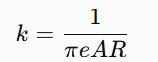

Wing Geometry
     ↓
AR
     ↓
Oswald efficiency
     ↓
k

**Propulsion assumptions**

In [12]:
# ============================================================
# 7. TURBOPROP PROPULSION PARAMETERS
# ============================================================
#
# Classification:
#   ENGINEERING ASSUMPTION
#
# These values are used for the first conceptual model.
# They are NOT presented as certified TBM engine data.
# ============================================================

propeller_efficiency = 0.85

BSFC_kg_kWh = 0.30

print(
    f"Propeller efficiency : "
    f"{propeller_efficiency:.2f}"
)

print(
    f"BSFC                 : "
    f"{BSFC_kg_kWh:.3f} kg/kWh"
)

Propeller efficiency : 0.85
BSFC                 : 0.300 kg/kWh


**INITIAL AIRCRAFT WEIGHT**

In [13]:
# ============================================================
# 8. INITIAL AIRCRAFT WEIGHT
# ============================================================
#
# Initial value comes from the Raymer weight-sizing stage.
# For this mission analysis we use the current design estimate.
# ============================================================

MTOW_kg = 3400.0

MTOW_N = (
    MTOW_kg
    * 9.80665
)

wing_area_m2 = mission[
    "wing_area_m2"
]

print(f"MTOW       : {MTOW_kg:.1f} kg")
print(f"Weight     : {MTOW_N:.1f} N")
print(f"Wing area  : {wing_area_m2:.2f} m²")

MTOW       : 3400.0 kg
Weight     : 33342.6 N
Wing area  : 18.00 m²


**CRUISE DYNAMIC PRESSURE**

In [14]:
# ============================================================
# 9. CRUISE DYNAMIC PRESSURE
# ============================================================

q_cruise = (
    0.5
    * rho_cruise
    * cruise_speed_mps ** 2
)

print(
    f"Dynamic pressure: "
    f"{q_cruise:.1f} Pa"
)

Dynamic pressure: 6537.6 Pa


**CRUISE LIFT COEFFICIENT**

In [15]:
# ============================================================
# 10. CRUISE LIFT COEFFICIENT
# ============================================================

CL_cruise = (
    MTOW_N
    / (
        q_cruise
        * wing_area_m2
    )
)

print(
    f"C_L cruise = "
    f"{CL_cruise:.4f}"
)

C_L cruise = 0.2833


**CRUISE DRAG COEFFICIENT**

In [16]:
# ============================================================
# 11. CRUISE DRAG COEFFICIENT
# ============================================================

CD_induced = (
    k
    * CL_cruise ** 2
)

CD_cruise = (
    CD0
    + CD_induced
)

print(
    f"CD0           = {CD0:.5f}"
)

print(
    f"CD induced    = {CD_induced:.5f}"
)

print(
    f"CD total      = {CD_cruise:.5f}"
)

CD0           = 0.02500
CD induced    = 0.00349
CD total      = 0.02849


**CRUISE L/D**

In [17]:
# ============================================================
# 12. CRUISE L/D
# ============================================================

LD_cruise = (
    CL_cruise
    / CD_cruise
)

print(
    f"Cruise L/D = "
    f"{LD_cruise:.2f}"
)

Cruise L/D = 9.94


**CRUISE DRAG AND SHAFT POWER**

In [18]:
# ============================================================
# 13. CRUISE DRAG AND SHAFT POWER
# ============================================================

drag_N = (
    q_cruise
    * wing_area_m2
    * CD_cruise
)

propulsive_power_W = (
    drag_N
    * cruise_speed_mps
)

shaft_power_W = (
    propulsive_power_W
    / propeller_efficiency
)

shaft_power_kW = (
    shaft_power_W / 1000
)

print(f"Cruise drag       : {drag_N:.1f} N")
print(f"Propulsive power  : {propulsive_power_W/1000:.1f} kW")
print(f"Shaft power       : {shaft_power_kW:.1f} kW")

Cruise drag       : 3352.7 N
Propulsive power  : 517.4 kW
Shaft power       : 608.8 kW


**BSFC CONVERSION FOR BREGUET EQUATION**

In [19]:
# ============================================================
# 14. BSFC CONVERSION FOR BREGUET EQUATION
# ============================================================

BSFC_kg_Ws = (
    BSFC_kg_kWh
    / (1000 * 3600)
)

print(
    f"BSFC = "
    f"{BSFC_kg_Ws:.8e} kg/(W·s)"
)

BSFC = 8.33333333e-08 kg/(W·s)


**BREGUET RANGE — TURBOPROP**

In [20]:
# ============================================================
# 15. BREGUET RANGE — TURBOPROP
# ============================================================
#
# R = (eta_p / c_p) * (L/D) * ln(W_initial / W_final)
#
# Therefore:
#
# W_final / W_initial =
#
# exp[
#   - R * c_p
#   / (eta_p * L/D)
# ]
# ============================================================

range_m = (
    mission["range_km"]
    * KM_TO_M
)

ln_weight_ratio = (
    range_m
    * BSFC_kg_Ws
    / (
        propeller_efficiency
        * LD_cruise
    )
)

Wf_Wi_cruise = np.exp(
    -ln_weight_ratio
)

cruise_fuel_fraction = (
    1 - Wf_Wi_cruise
)

print(
    f"Range                     : "
    f"{range_m/1000:.1f} km"
)

print(
    f"W_final / W_initial       : "
    f"{Wf_Wi_cruise:.5f}"
)

print(
    f"Cruise fuel fraction      : "
    f"{cruise_fuel_fraction:.4f}"
)

Range                     : 3000.0 km
W_final / W_initial       : 0.97086
Cruise fuel fraction      : 0.0291


**RESERVE / LOITER**

In [21]:
# ============================================================
# 16. RESERVE / LOITER
# ============================================================

loiter_speed_mps = (
    mission["loiter_speed_kt"]
    * KT_TO_MPS
)

reserve_time_s = (
    mission["reserve_time_min"]
    * MIN_TO_S
)

print(
    f"Loiter speed : "
    f"{loiter_speed_mps:.2f} m/s"
)

print(
    f"Reserve time : "
    f"{reserve_time_s/60:.1f} min"
)

Loiter speed : 61.73 m/s
Reserve time : 45.0 min


**LOITER FUEL FRACTION**

In [22]:

# ============================================================
# 17. LOITER FUEL FRACTION
# ============================================================
#
# For the first conceptual model we use:
#
#   fuel_fraction =
#       1 - exp(-c * P_specific * t)
#
# A more detailed propeller loiter model will be introduced
# later when the propulsion model is expanded.
# ============================================================

loiter_fuel_fraction = (
    1
    - np.exp(
        -BSFC_kg_Ws
        * shaft_power_W
        * reserve_time_s
        / MTOW_kg
    )
)

print(
    f"Loiter fuel fraction = "
    f"{loiter_fuel_fraction:.5f}"
)

Loiter fuel fraction = 0.03948


**MISSION SEGMENT WEIGHT FRACTIONS**

In [23]:
# ============================================================
# 18. MISSION SEGMENT WEIGHT FRACTIONS
# ============================================================

mission_segments = pd.DataFrame([
    
    ["Takeoff", 0.970, "RAYMER / CONCEPTUAL"],
    
    ["Climb", 0.985, "RAYMER / CONCEPTUAL"],
    
    ["Cruise", Wf_Wi_cruise, "BREGUET / PHYSICS"],
    
    ["Descent", 0.990, "RAYMER / CONCEPTUAL"],
    
    ["Reserve / Loiter",
     1 - loiter_fuel_fraction,
     "PHYSICS / FIRST-ORDER"],
    
    ["Landing", 0.995, "RAYMER / CONCEPTUAL"],
    
], columns=[
    "segment",
    "W_after_W_before",
    "source"
])

mission_segments

,segment,W_after_W_before,source
0,Takeoff,0.970000,RAYMER / CONCEPTUAL
1,Climb,0.985000,RAYMER / CONCEPTUAL
2,Cruise,0.970858,BREGUET / PHYSICS
3,Descent,0.990000,RAYMER / CONCEPTUAL
4,Reserve / Loiter,0.960516,PHYSICS / FIRST-ORDER
5,Landing,0.995000,RAYMER / CONCEPTUAL


**TOTAL MISSION WEIGHT FRACTION**

In [24]:
# ============================================================
# 19. TOTAL MISSION WEIGHT FRACTION
# ============================================================

total_mission_weight_fraction = np.prod(
    mission_segments[
        "W_after_W_before"
    ]
)

total_mission_fuel_fraction = (
    1
    - total_mission_weight_fraction
)

print(
    f"Total mission weight fraction : "
    f"{total_mission_weight_fraction:.5f}"
)

print(
    f"Total mission fuel fraction   : "
    f"{total_mission_fuel_fraction:.5f}"
)

Total mission weight fraction : 0.87766
Total mission fuel fraction   : 0.12234


**MISSION WEIGHT PROGRESSION**

In [25]:
# ============================================================
# 20. MISSION WEIGHT PROGRESSION
# ============================================================

weight_fraction = 1.0

mission_progression = []

for _, row in mission_segments.iterrows():

    weight_fraction *= row["W_after_W_before"]

    mission_progression.append(
        {
            "segment": row["segment"],
            "weight_fraction": weight_fraction
        }
    )

df_mission_progression = pd.DataFrame(
    mission_progression
)

df_mission_progression

,segment,weight_fraction
0,Takeoff,0.970000
1,Climb,0.955450
2,Cruise,0.927607
3,Descent,0.918331
4,Reserve / Loiter,0.882071
5,Landing,0.877660


**MISSION WEIGHT FRACTION PLOT**

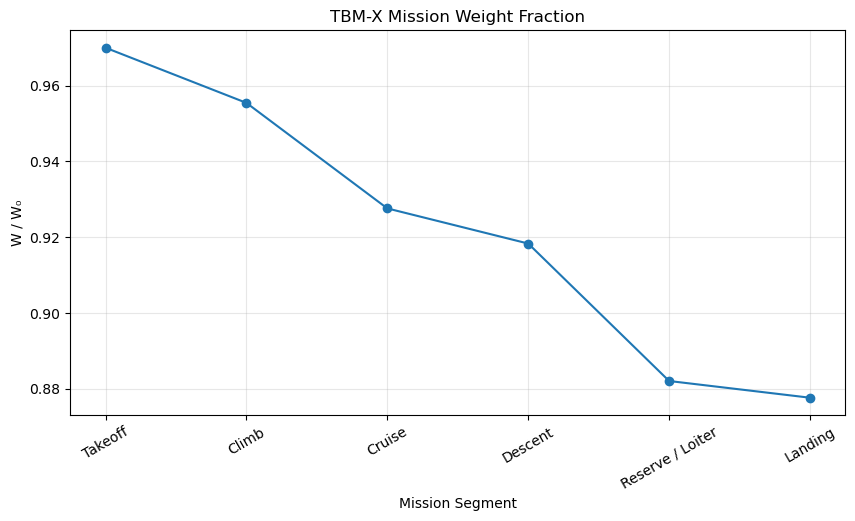

In [26]:
# ============================================================
# 21. MISSION WEIGHT FRACTION PLOT
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    df_mission_progression["segment"],
    df_mission_progression["weight_fraction"],
    marker="o"
)

plt.xlabel("Mission Segment")
plt.ylabel("W / W₀")

plt.title(
    "TBM-X Mission Weight Fraction"
)

plt.xticks(rotation=30)

plt.grid(alpha=0.3)

plt.show()

**MISSION FUEL WEIGHT**

In [27]:
# ============================================================
# 22. MISSION FUEL WEIGHT
# ============================================================

fuel_weight_kg = (
    MTOW_kg
    * total_mission_fuel_fraction
)

fuel_weight_lb = (
    fuel_weight_kg
    * KG_TO_LB
)

print(
    f"Mission fuel weight : "
    f"{fuel_weight_kg:.1f} kg"
)

print(
    f"Mission fuel weight : "
    f"{fuel_weight_lb:.1f} lb"
)

Mission fuel weight : 416.0 kg
Mission fuel weight : 917.0 lb


**FUEL VOLUME ESTIMATION**

In [28]:
# ============================================================
# 23. FUEL VOLUME ESTIMATION
# ============================================================
#
# Engineering assumption:
#   Jet-A density ≈ 0.80 kg/L
#
# This is a conceptual conversion only.
# Actual fuel density depends on fuel specification
# and temperature.
# ============================================================

fuel_density_kg_L = 0.80

fuel_volume_L = (
    fuel_weight_kg
    / fuel_density_kg_L
)

print(
    f"Estimated fuel volume : "
    f"{fuel_volume_L:.1f} L"
)

Estimated fuel volume : 519.9 L


**Benchmark comparison**

In [34]:
# ============================================================
# 24. BENCHMARK VALIDATION
# ============================================================



from pathlib import Path

possible_paths = [
    Path("../03_benchmark_database/TBM_X_Master_v0_2.csv"),
    Path("../data/processed/TBM_X_Master_v0_2.csv"),
    Path("data/processed/TBM_X_Master_v0_2.csv"),
]

benchmark_path = None

for path in possible_paths:
    if path.exists():
        benchmark_path = path
        break

if benchmark_path is None:
    raise FileNotFoundError(
        "TBM-X Master benchmark dataset bulunamadı."
    )

benchmark = pd.read_csv(
    benchmark_path
)

print(
    f"Benchmark file: {benchmark_path}"
)

print(
    f"Rows: {len(benchmark)}"
)

Benchmark file: data\processed\TBM_X_Master_v0_2.csv
Rows: 5


**Benchmark summary**

In [33]:
# ============================================================
# 25. BENCHMARK SUMMARY
# ============================================================

benchmark[
    [
        "aircraft_id",
        "MTOW_kg",
        "wing_area_m2",
        "max_cruise_speed_m_s",
        "takeoff_power_kW",
        "usable_fuel_L"
    ]
]

,aircraft_id,MTOW_kg,wing_area_m2,max_cruise_speed_m_s,takeoff_power_kW,usable_fuel_L
0,TBM960,3454.000000,18.0,169.766667,667.401385,1106.000000
1,TBM910,3353.861984,NaN,167.708889,633.844891,1101.554829
2,TBM940,3354.000000,NaN,NaN,633.844891,1101.554829
3,PC12NGX,4740.040267,NaN,149.188889,NaN,1521.735537
4,M600SLS,2721.554220,NaN,140.957778,447.419923,984.207064


**INITIAL DESIGN VS BENCHMARK**

In [36]:
# ============================================================
# 26. TBM-X INITIAL DESIGN VS BENCHMARK
# ============================================================

benchmark_summary = (
    benchmark[
        [
            "aircraft_id",
            "MTOW_kg",
            "wing_area_m2",
            "max_cruise_speed_m_s",
            "takeoff_power_kW",
            "usable_fuel_L"
        ]
    ]
    .groupby("aircraft_id")
    .first()
    .reset_index()
)

tbmx_summary = pd.DataFrame({
    "aircraft_id": ["TBM-X"],
    "MTOW_kg": [MTOW_kg],
    "wing_area_m2": [wing_area_m2],
    "max_cruise_speed_m_s": [cruise_speed_mps],
    "takeoff_power_kW": [shaft_power_kW],
    "usable_fuel_L": [fuel_volume_L],
})

comparison = pd.concat(
    [
        benchmark_summary,
        tbmx_summary
    ],
    ignore_index=True
)

comparison

,aircraft_id,MTOW_kg,wing_area_m2,max_cruise_speed_m_s,takeoff_power_kW,usable_fuel_L
0,M600SLS,2721.554220,NaN,140.957778,447.419923,984.207064
1,PC12NGX,4740.040267,NaN,149.188889,NaN,1521.735537
2,TBM910,3353.861984,NaN,167.708889,633.844891,1101.554829
3,TBM940,3354.000000,NaN,NaN,633.844891,1101.554829
4,TBM960,3454.000000,18.0,169.766667,667.401385,1106.000000
5,TBM-X,3400.000000,18.0,154.333200,608.750955,519.942886


**ENGINEERING DIAGNOSTICS**

In [37]:
# ============================================================
# 27. ENGINEERING DIAGNOSTICS
# ============================================================

print("=" * 60)
print("TBM-X ENGINEERING DIAGNOSTICS")
print("=" * 60)

print(
    f"\nCruise L/D              : {LD_cruise:.2f}"
)

print(
    f"Cruise CL               : {CL_cruise:.4f}"
)

print(
    f"Cruise CD               : {CD_cruise:.4f}"
)

print(
    f"Cruise shaft power      : {shaft_power_kW:.1f} kW"
)

print(
    f"Cruise fuel fraction    : "
    f"{cruise_fuel_fraction:.4f}"
)

print(
    f"Total mission fuel frac.: "
    f"{total_mission_fuel_fraction:.4f}"
)

print(
    f"Estimated fuel volume   : "
    f"{fuel_volume_L:.1f} L"
)

TBM-X ENGINEERING DIAGNOSTICS

Cruise L/D              : 9.94
Cruise CL               : 0.2833
Cruise CD               : 0.0285
Cruise shaft power      : 608.8 kW
Cruise fuel fraction    : 0.0291
Total mission fuel frac.: 0.1223
Estimated fuel volume   : 519.9 L


**CD0 SENSITIVITY**

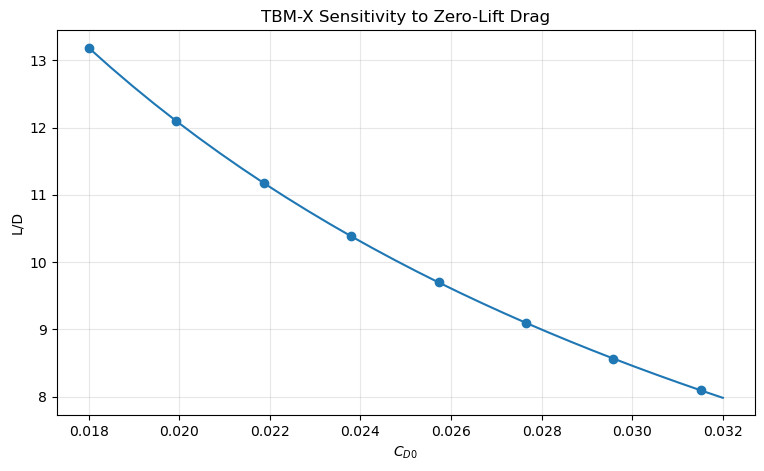

In [38]:
# ============================================================
# 28. CD0 SENSITIVITY
# ============================================================

CD0_values = np.linspace(
    0.018,
    0.032,
    30
)

LD_values = []

for cd0 in CD0_values:

    cd = (
        cd0
        + k * CL_cruise**2
    )

    ld = (
        CL_cruise
        / cd
    )

    LD_values.append(ld)

plt.figure(figsize=(9, 5))

plt.plot(
    CD0_values,
    LD_values,
    marker="o",
    markevery=4
)

plt.xlabel("$C_{D0}$")
plt.ylabel("L/D")

plt.title(
    "TBM-X Sensitivity to Zero-Lift Drag"
)

plt.grid(alpha=0.3)

plt.show()

**PROPELLER EFFICIENCY SENSITIVITY**

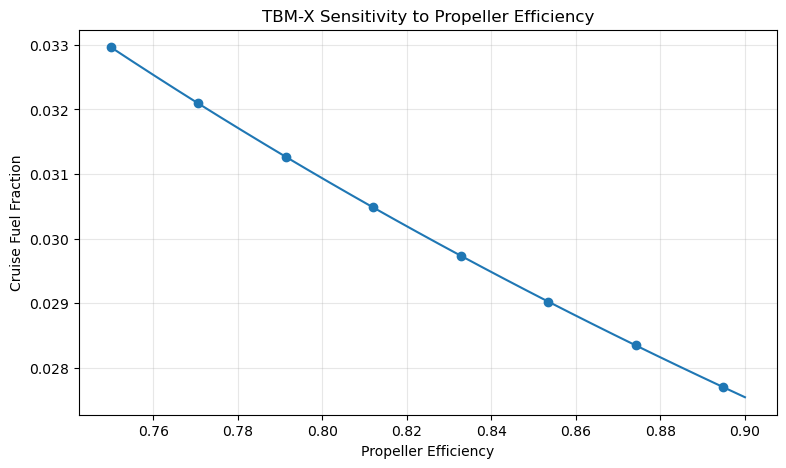

In [39]:
# ============================================================
# 29. PROPELLER EFFICIENCY SENSITIVITY
# ============================================================

eta_values = np.linspace(
    0.75,
    0.90,
    30
)

fuel_fraction_eta = []

for eta in eta_values:

    ln_ratio = (
        range_m
        * BSFC_kg_Ws
        / (
            eta
            * LD_cruise
        )
    )

    weight_fraction = np.exp(
        -ln_ratio
    )

    fuel_fraction_eta.append(
        1 - weight_fraction
    )

plt.figure(figsize=(9, 5))

plt.plot(
    eta_values,
    fuel_fraction_eta,
    marker="o",
    markevery=4
)

plt.xlabel("Propeller Efficiency")
plt.ylabel("Cruise Fuel Fraction")

plt.title(
    "TBM-X Sensitivity to Propeller Efficiency"
)

plt.grid(alpha=0.3)

plt.show()

**Final report**

In [40]:
# ============================================================
# 30. MISSION ANALYSIS SUMMARY
# ============================================================

mission_summary = pd.DataFrame({
    
    "Parameter": [
        "Range",
        "Cruise altitude",
        "Cruise speed",
        "Wing area",
        "MTOW",
        "Cruise CL",
        "Cruise CD",
        "Cruise L/D",
        "Shaft power",
        "Cruise fuel fraction",
        "Total mission fuel fraction",
        "Estimated fuel volume",
    ],
    
    "Value": [
        mission["range_km"],
        mission["cruise_altitude_ft"],
        mission["cruise_speed_kt"],
        wing_area_m2,
        MTOW_kg,
        CL_cruise,
        CD_cruise,
        LD_cruise,
        shaft_power_kW,
        cruise_fuel_fraction,
        total_mission_fuel_fraction,
        fuel_volume_L,
    ],
    
    "Unit": [
        "km",
        "ft",
        "kt",
        "m²",
        "kg",
        "-",
        "-",
        "-",
        "kW",
        "-",
        "-",
        "L",
    ]
})

mission_summary

,Parameter,Value,Unit
0,Range,3000.000000,km
1,Cruise altitude,25000.000000,ft
2,Cruise speed,300.000000,kt
3,Wing area,18.000000,m²
4,MTOW,3400.000000,kg
5,Cruise CL,0.283341,-
6,Cruise CD,0.028491,-
7,Cruise L/D,9.944899,-
8,Shaft power,608.750955,kW
9,Cruise fuel fraction,0.029142,-


**MISSION ANALYSIS — CONCLUSION**

In [41]:
# ============================================================
# TBM-X MISSION ANALYSIS — CONCLUSION
# ============================================================

print("=" * 70)
print("TBM-X — RAYMER MISSION ANALYSIS COMPLETE")
print("=" * 70)

print("""
The mission model has been evaluated using:

    ✓ Mission requirements
    ✓ ISA atmosphere
    ✓ Cruise aerodynamics
    ✓ Lift / drag estimation
    ✓ L/D calculation
    ✓ Turboprop Breguet range relation
    ✓ Cruise fuel fraction
    ✓ Reserve / loiter approximation
    ✓ Total mission fuel fraction
    ✓ Benchmark comparison
    ✓ Parameter sensitivity analysis

Next step:

    MISSION FUEL FRACTION
              ↓
       RAYMER WEIGHT LOOP
              ↓
          UPDATED MTOW
              ↓
       UPDATED AERODYNAMICS
              ↓
       UPDATED FUEL FRACTION
              ↓
            ITERATE
""")

TBM-X — RAYMER MISSION ANALYSIS COMPLETE

The mission model has been evaluated using:

    ✓ Mission requirements
    ✓ ISA atmosphere
    ✓ Cruise aerodynamics
    ✓ Lift / drag estimation
    ✓ L/D calculation
    ✓ Turboprop Breguet range relation
    ✓ Cruise fuel fraction
    ✓ Reserve / loiter approximation
    ✓ Total mission fuel fraction
    ✓ Benchmark comparison
    ✓ Parameter sensitivity analysis

Next step:

    MISSION FUEL FRACTION
              ↓
       RAYMER WEIGHT LOOP
              ↓
          UPDATED MTOW
              ↓
       UPDATED AERODYNAMICS
              ↓
       UPDATED FUEL FRACTION
              ↓
            ITERATE



**Project Architecture**

                REQUIREMENTS
                     │
                     ▼
              INITIAL MTOW
                     │
                     ▼
             MISSION ANALYSIS
                     │
          ┌──────────┴──────────┐
          ▼                     ▼
     Aerodynamics          Propulsion
          │                     │
          └──────────┬──────────┘
                     ▼
                 BREGUET
                     │
                     ▼
              FUEL FRACTION
                     │
                     ▼
              WEIGHT SIZING
                     │
                     ▼
                  MTOW
                     │
                     └──────────────┐
                                    │
                                    ▼
                                ITERATION

**TARGET LOOPS**

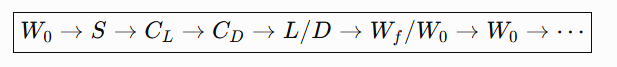

**TARGET ==>**

In [43]:
print(
"""
05  Weight ↔ Mission Iteration
        ↓
06  Raymer Geometry Sizing
        ↓
07  Aerodynamic Model
        ↓
08  Propulsion Model
        ↓
09  Performance
        ↓
10  Stability
        ↓
11  Full Mission
        ↓
12  Large Design Dataset
        ↓
13  EDA
        ↓
14  ML / Surrogate
        ↓
15  UQ
        ↓
16  Optimization
        ↓
17  Decision
        ↓
       TBM-X
""" )      


05  Weight ↔ Mission Iteration
        ↓
06  Raymer Geometry Sizing
        ↓
07  Aerodynamic Model
        ↓
08  Propulsion Model
        ↓
09  Performance
        ↓
10  Stability
        ↓
11  Full Mission
        ↓
12  Large Design Dataset
        ↓
13  EDA
        ↓
14  ML / Surrogate
        ↓
15  UQ
        ↓
16  Optimization
        ↓
17  Decision
        ↓
       TBM-X

